**Note**: This notebook should take around **three minutes** to run.

For a more comprehensive and detailed treatment of this problem, please refer to the [GitHub repository](https://github.com/HighDimensionalEconLab/symmetry_dynamic_programming).

# $\text{The Economic Problem}$:
$\text{The first order condition can be written as}$:

$
\begin{align}
&\gamma u(X) - \beta~\mathbb{E}\big[P(X')+ \gamma (1-\delta) u(X')\big]=0\\
\end{align}
$

$\text{subject to the following law of motion}$

$
\begin{align}
&X' = \{(1-\delta) \hat{x} + u(X + \sigma \hat{w} + \eta \omega), \text{for}~(\hat{x},\hat{w})\in (X,W)\}
\end{align}
$

where 

1. $u: \mathbb{R}^N\rightarrow \mathbb{R}$ $\text{is the adjustment/investmen function}$


2. $N$ $\text{is the number of firms}$


3. $W \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_{N\times N})$ $\text{is the idiosyncratic shock}$


4. $P(X') = \alpha_0 + \alpha_1 \frac{1}{N} \sum_{i=1}^N X^{\prime \nu}_i$ $\text{is the inverse demand function}$


5. $\gamma$ $\text{is the adjustment coefficient}$ and $\delta$ $\text{is the depreciation rate}$


6. $\sigma$ $\text{is the standard deviation of the idiosyncratic shock}$


7. $\eta$ $\text{is the standard deviation of the aggregate shock}$


8. $\nu$ $\text{is the curvature coefficient of the inverse demand function}$


$\text{In this example, we focus on the case of:}$


1. $N = 128$

2. $\alpha_0 = 1.0$ and  $\alpha_1 = 1.0$ 
 
3. $\beta = 0.95$, $\gamma = 90.0$, $\nu  = 1.0$, and $\delta =  0.05$

4. $\sigma = 0.005$ and $\eta = 0.001$ 





#### Importing Packages

In [1]:
import numpy as np
import quantecon
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
torch.manual_seed(123) # fixing the seed

#### Setting Up the Economic Parameters 


In [3]:
N = 128 # Number of firms
alpha_0 = 1.0 # Price coefficient
alpha_1 = 1.0 # Price coefficient
beta = 0.95 # Discount factor
gamma = 90.0 # Adjustment cost coefficient 
sigma = 0.005 # Idiosyncratic shock standard deviation 
delta =  0.05 # Depreciation rate
eta = 0.001 # Aggregate shock standard deviation
nu  = 1.0 # The demand curvature

### Setting Up the Grid ($\mathcal{X}_{\text{train}}$) and the DataLoader
1. Generating an intial condition for the economy: $X_0$
2. Given the initial condition $X_0$, and initial guess $u_0$, realizations of idiosyncratic and aggregate shocks, generating some trajectories of length $T$ to use for $\mathcal{X}_{\text{train}}$  

3. We use a linear policy for initial simulation: $u_0(X) = h_0 + \frac{h_1}{N}\sum_{i=1}^N X_i$ 

3.a) $h_0>0$ and $h_1<0$ guarantees stationarity and positivity. 

3.b) $|\frac{h_0}{h_1}|<1$ guarantees the positivity of the prices in the sample, i.e., $p(X)>0$

In [4]:
# The initial state of the economy: X_0
X_0_loc =  0.9
X_0_scale = 0.05
X_0 = torch.normal(X_0_loc, X_0_scale, size=(N,)).abs()

In [5]:
# Generating the initial simulated path
T = 63 # Length of the paths or trajectories
num_trajectories = 16 # Number of trajectories/path generated

def u_0(X): # The initial guess to generate the trajectories
    return 0.2 - 0.3*X.mean(1, keepdim=True) #h_0 = 0.2, h_1 = -0.3
 

In [6]:
# Creating the idiosyncratic and aggregate shocks
w = torch.randn(num_trajectories,T,N,) #idiosyncratic shocks
omega = torch.randn(num_trajectories,T,1,) #aggregate shocks

In [7]:
data = torch.zeros(num_trajectories,T+1 ,N)

data[:, 0, :] = X_0
for t in range(T):
    data[:, t + 1, :] = u_0(data[:, t, :]) + (1 - delta) * data[:, t, :] + sigma* w[:,t,:]+ eta * omega[:, t]

data = data.flatten(start_dim=0, end_dim=1) # Turning the matrix into a tensor

In [8]:
data_loader = DataLoader(data, batch_size=16, shuffle= True)

#### Setting up the Neural Network

Here we use the $\Phi(\text{ReLU})$ structure, for the `moment-based` structure refer to this [code](https://github.com/HighDimensionalEconLab/econ_layers/blob/982f5658064a3f6efcd53d309d154b443cd48ba7/econ_layers/layers.py#L216-L254).

This is an approximation for the invetment/adjustment policy $\hat{u}: \mathbb{R}^N \rightarrow \mathbb{R}$, where $N$ is the number of agents.

The symmetry induces a structure on the design of the neural network:

$\begin{align}
\hat{u}(X) = \rho\big(\frac{1}{N}\sum_{i=1}^N\phi(X_i)\big)
\end{align}$


where $\phi:\mathbb{R}\rightarrow \mathbb{R}^L$ and $\rho:\mathbb{R}^L\rightarrow \mathbb{R}$

Both $\rho$ and $\phi$ are going to be represented with a neural netwrok.


In [9]:
L = 4

In [10]:
class U_hat_NN(nn.Module):
    def __init__(self,
                 dim_hidden = 128,):
        super().__init__()
        
        self.rho = nn.Sequential(
            nn.Linear(L, dim_hidden),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias=True),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias=True),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias=True),
            nn.ReLU(), 
            nn.Linear(dim_hidden, 1),
        )
        
        self.phi = nn.Sequential(
            nn.Linear(1, dim_hidden),
            nn.ReLU(), #You can replace it with nn.Tanh()
            nn.Linear(dim_hidden, L, bias=True),
        )
        
        
    def forward(self, X):
        num_batches, N = X.shape
        phi_X = torch.stack(
            [torch.mean(self.phi(X[i, :].reshape([N, 1])), 0) for i in range(num_batches)]
        )
        return self.rho(phi_X)

#### Initializing the Neural Network and Defining the Optimizer

In [11]:
u_hat= U_hat_NN()
learning_rate = 1e-3
optimizer = torch.optim.Adam(u_hat.parameters(), lr=learning_rate) #Adam Optimizer 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8) #dampening the learning rate

In [12]:
num_epochs = 21 # step of optimization
print_epoch_frequency = 10 # how often printing the results

### Implementing the Economics 
Here we implement the economic conditions in the `residuals` function to be minimized 

1. The `residuals` function implmenets the Euler residuals (i.e., Eq.1) 

 1.a) Given an approximate funtion $\hat{u}$ and the shocks, we $X'$ (i.e., Eq.2)
 
 1.b) With one draw of idiosyncratic shocks we calculate $\mathbb{E}\big[ p(X')+ \gamma (1-\delta)\hat{u}(X')|\omega\big]$
 
 1.c) We use Gaussian quadratures to calculate the expectation with respect to $\omega$ (aggregate shock) 



In [13]:
# One draw of idiosyncratic shocks to calcualte expectation wrt to idiosyncratic shocks
one_draw_idio_vec = torch.randn(1, N) 
one_draw_idio = (one_draw_idio_vec - one_draw_idio_vec.mean()) / one_draw_idio_vec.std() #Normalizing to make sure it is mean zero


In [14]:
# Gaussian quadrature nodes to calculate expectation wrt to aggregate shocks
omega_quadrature_nodes = 7 # number of nodes
nodes, weights = quantecon.quad.qnwnorm(omega_quadrature_nodes)
quadrature_nodes = torch.tensor(nodes, dtype=torch.float32)
quadrature_weights = torch.tensor(weights, dtype=torch.float32)

In [15]:
def residuals(batch):
    X = batch
    
    #u(X)
    u_X = u_hat(X)
    
    # X'
    X_primes = torch.stack([u_X + (1 - delta) * X + sigma * one_draw_idio + eta * node for node in quadrature_nodes]).type_as(X)
    
    #p(X'): price next period
    p_primes = alpha_0 - alpha_1 * X_primes.pow(nu).mean(2)
    
    #E[p(X')]
    Ep = (p_primes.T @ quadrature_weights).type_as(X).reshape(-1, 1)
    
    #E[u(X')]
    Eu = ((torch.stack(tuple(u_hat(X_primes[i]) for i in range(len(quadrature_nodes)))).squeeze(2).T@ quadrature_weights)
          .type_as(X).reshape(-1, 1))
    
    # Euler residuals
    residuals = gamma * u_X - beta * (Ep + gamma * (1 -delta) * Eu) 
    
    return residuals

### Training Loop (Optimization Process)
Here, we minimize the mean squared of Euler residuals over the grid points:

$\min_{\theta} \frac{1}{|\mathcal{X}_{\text{train}}|} \sum_{X\in \mathcal{X}_{\text{train}}} \bigg(\gamma u(X;\theta) - \beta~\mathbb{E}\big[P(X')+ \gamma (1-\delta) \hat{u}(X';\theta)\big]\bigg)^2$

where $X'$ is calculated by the law of motion and $\theta$ is the coefficients of the neural network, and the optimization is done with gradient-based optimizers such as `Gradient Descent (GD)` and `Adam`. 

In [16]:
for epoch in range(num_epochs):
    for batch in data_loader:
        
        optimizer.zero_grad() # Resetting the gradients (with respect to NN coefficients)
        
        Euler_res = residuals(batch) # Constructing the Euler and initial condition residuals
        
        loss = Euler_res.pow(2).mean() # Calculating the mean squared (over the grid points) of Euler residuals
        
        
        loss.backward() # Calculating the gradients (with respect to NN coefficients)
        optimizer.step() # Using the gradients to minimize the loss function
        
    scheduler.step() # Dampening the learning rate
    
    if epoch % print_epoch_frequency == 0:
        print(f"epoch = {epoch}, loss = {loss.detach().numpy():.2e}")


epoch = 0, loss = 8.95e-03
epoch = 10, loss = 5.59e-07
epoch = 20, loss = 2.81e-07


### Plotting the Results

#### Calculating the Approxiamte $\hat{u}$ Path: Deep Learning Solution 

In [17]:
torch.manual_seed(234) # Changing the seed to obtain new idiosyncratic and aggeregate shocks

In [18]:
w_test = torch.randn(num_trajectories,T,N,) # Test idiosyncratic shocks
omega_test = torch.randn(num_trajectories,T,1,) # Test aggregate shocks

In [19]:
data_test = torch.zeros(num_trajectories,T+1 ,N)

data_test[:, 0, :] = X_0
for t in range(T):
    data_test[:, t + 1, :] = u_hat(data_test[:, t, :]) + (1 - delta) * data_test[:, t, :] + sigma* w_test[:,t,:]+ eta * omega_test[:, t]


In [20]:
trajectory_1_test = data_test[0,:,:] # Picking the first set trajectories generate by deep learning

u_hat_path_test = u_hat(trajectory_1_test).detach() # Calculating u_hat path 

#### Calculating the Benchmark $u$ Path: Using Linear-Quadratic Method 
Here the linear quadratic solution is manually imported, for seeing the details of Linear-Quadratic solution refer to this [code](https://github.com/HighDimensionalEconLab/symmetry_dynamic_programming/blob/d3b4d8d0e1e66b4a396422a6c8ef294ab64d7a21/investment_euler.py#L67-L101)

In [21]:
def u_ref_lq(X):
    H_0 = 0.06872243906482536 # The linear quadratic solution coefficients
    H_1 = -0.05046135500134341 # The linear quadratic solution coefficients
    return H_0 + H_1 * X.mean(1, keepdim=True)

In [22]:
data_test_lq = torch.zeros(num_trajectories,T+1 ,N)

data_test_lq[:, 0, :] = X_0
for t in range(T):
    data_test_lq[:, t + 1, :] = u_ref_lq(data_test_lq[:, t, :]) + (1 - delta) *data_test_lq[:, t, :] + sigma* w_test[:,t,:]+ eta * omega_test[:, t]

In [23]:
trajectory_1_lq_test = data_test_lq[0,:,:] # Picking the first set trajectories generated by the LQ solution

u_ref_path_test = u_hat(trajectory_1_lq_test).detach() # Calculating u_ref path (LQ solution)

#### Plots
We plot both equilibrium path of (i.e.,  $\hat{u}$ and $u_{\text{ref}}$)  and the relative errors between these two solutions, defined as:

$
\begin{align}
\varepsilon_{rel}(X_t) = \bigg|\frac{\hat{u}(X_t)- u_{\text{ref}}(X_t)}{u_{ref}(X_t)}\bigg|
\end{align}
$

In [24]:
relative_error = ((u_hat_path_test-u_ref_path_test)/u_ref_path_test).abs()

#### Plot Settings
such as font, font size and image size.

In [25]:
fontsize= 14
ticksize = 14
figsize = (14, 4.5)
params = {'font.family':'serif',
    "figure.figsize":figsize,
    'figure.dpi': 80,
    'figure.edgecolor': 'k',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': ticksize,
    'ytick.labelsize': ticksize
}
plt.rcParams.update(params)

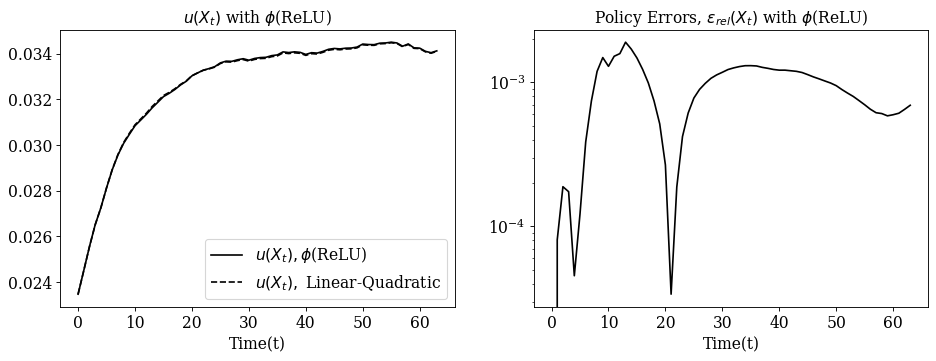

In [26]:
plt.subplot(1, 2 , 1)

plt.plot(u_hat_path_test, color='k',  label = r"$u(X_t), \phi$(ReLU)")
plt.plot(u_ref_path_test, color='k', linestyle= "--"  ,label = r"$u(X_t),$ Linear-Quadratic")
plt.xlabel(r"Time(t)")
plt.title(r"$u(X_t)$ with $\phi$(ReLU)")
plt.legend(loc='best')

plt.subplot(1, 2 , 2)

plt.plot(relative_error, color='k')
plt.xlabel(r"Time(t)")
plt.title(r"Policy Errors, $\varepsilon_{rel}(X_t)$ with $\phi$(ReLU)")
plt.yscale('log')

